# Optimization

## Overview

The `polykin.math.optimization` module provides both univariate and multivariate solvers for smooth objective functions.

|                     |   Derivative-free  | Derivative-based |
|---------------------|:------------------:|:----------------:|
| Univariate (scalar) |    `fmin_brent`    |   `fmin_secant`  |
| Multivariate        | `fmin_nelder_mead` |  `fmin_qnewton`  |

The scalar solvers return an `OptimumResult`, while the multivariate solvers return a `VectorOptimumResult` with the estimated minimizer, objective value, convergence message, and iteration counters.

## Univariate Function

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from polykin.math.optimization import fmin_brent, fmin_secant

### Lennard-Jones Potential

The Lennard-Jones potential is a standard one-dimensional test problem with a single attractive well. For $\sigma = \epsilon = 1$, the exact minimum is at $r^\star = 2^{1/6}$, which gives a useful reference when checking the numerical result.

In [2]:
def lennard_jones(r):
    sigma = 1.0
    epsilon = 1.0
    return 4 * epsilon * ((sigma/r)**12 - (sigma/r)**6)

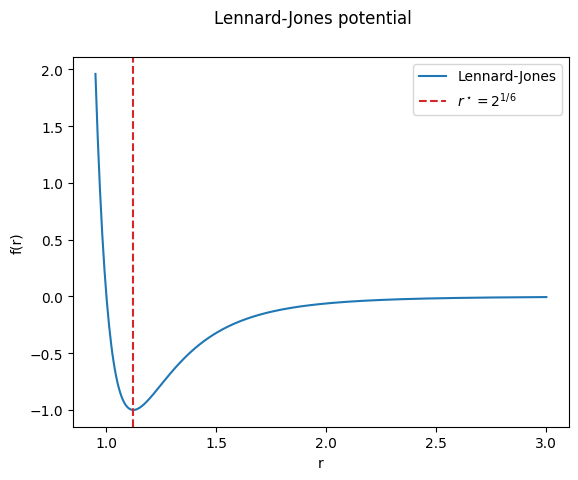

In [3]:
fig, ax = plt.subplots()
fig.suptitle("Lennard-Jones potential")

r = np.linspace(0.95, 3.0, 400)
r_star = 2 ** (1 / 6)
ax.plot(r, lennard_jones(r), label="Lennard-Jones")
ax.axvline(r_star, color="tab:red", linestyle="--", label=r"$r^\star = 2^{1/6}$")
ax.set_xlabel("r")
ax.set_ylabel("f(r)")
ax.legend();

When a bracket containing the minimum is available, Brent's method is the safest choice. It does not require derivatives, preserves the bracket, and usually converges rapidly on smooth functions.

In [4]:
fmin_brent(lennard_jones, 1.0, 3.0)

 method: Brent
success: True
message: |Δx| ≤ tolx
 nfeval: 13
  niter: 13
      x: 1.12246221e+00
      f: -1.00000000e+00

The secant method targets the stationary point through numerical derivatives, so it can be very efficient when the starting guesses are already close to the minimizer. Here we use complex-step differentiation, which is accurate for functions that accept complex inputs.

In [5]:
fmin_secant(lennard_jones, 1.0, 1.01, diff_scheme="complex")

 method: Secant
success: True
message: |f'(x)| ≤ tolg
 nfeval: 10
  niter: 8
      x: 1.12246205e+00
      f: -1.00000000e+00
     df: -3.87659504e-09

The trade-off is robustness. If the initial guesses are too far from the well, the derivative-based iteration can leave the attractive basin and fail to locate the minimum.

In [6]:
fmin_secant(lennard_jones, 1.5, 1.6, diff_scheme="complex")

 method: Secant
success: False
message: Function value increased from -0.2242077243863605 at x[k-1]=1.6 to -0.10963081822561647 at x[k]=1.8125241675252626.
 nfeval: 3
  niter: 1
      x: 1.81252417e+00
      f: -1.09630818e-01
     df: 3.52378708e-01

The near-minimum secant run converges to the same optimum as Brent's method, but the second run shows why `fmin_secant` should be treated as a local solver.

- use `fmin_brent` when you can bracket the minimum and want robust convergence;
- use `fmin_secant` when the function is smooth and you already have two good initial guesses.

## Multivariate Function


In [7]:
from polykin.math.optimization import fmin_nelder_mead, fmin_qnewton

## Himmelblau's function

Himmelblau's function is a standard two-dimensional test problem with four equivalent local minima. That makes it useful for visualizing how a solver moves through the objective landscape and how strongly the result depends on the starting point.

We start both methods from the same initial guess, $x_0 = (0, 0)$, and record their iterates through a callback so the optimization paths can be plotted on top of the contour map.

In [8]:
def himmelblau(z):
    """Himmelblau's function for 2D optimization."""
    x, y = z
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

def himmelblau_grad(z):
    """Analytical gradient of Himmelblau's function (for BFGS)."""
    x, y = z
    dx = 4*x*(x**2 + y - 11) + 2*(x + y**2 - 7)
    dy = 2*(x**2 + y - 11) + 4*y*(x + y**2 - 7)
    return np.array([dx, dy])

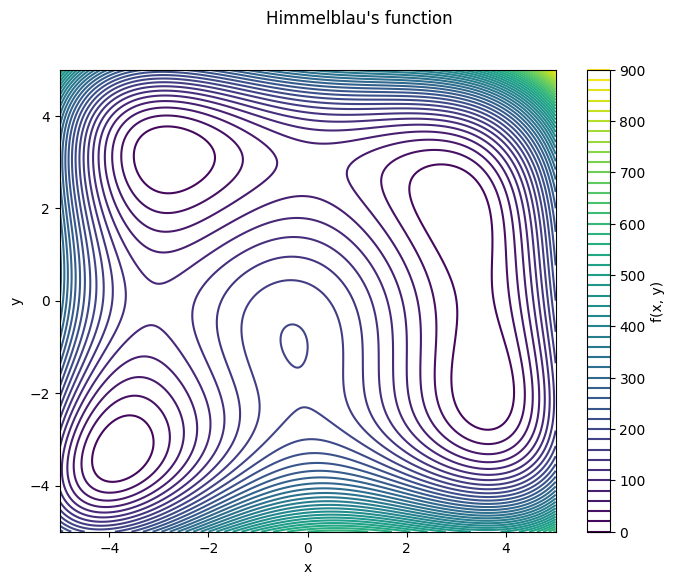

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle("Himmelblau's function")

x = np.linspace(-5, 5, 400)
y = x
X, Y = np.meshgrid(x, y)
Z = himmelblau([X, Y])

contours = ax.contour(X, Y, Z, levels=50, cmap="viridis")
fig.colorbar(contours, ax=ax, label="f(x, y)")
ax.set_xlabel("x")
ax.set_ylabel("y");

`fmin_nelder_mead` does not use derivatives. This makes the method robust on rough problems, but typically slower than gradient-based alternatives on smooth functions.

The method also accepts a callback function, which we can use to record the solution trajectory.

In [10]:
path_nelder_mead = []
def callback_nelder_mead(k, xk, fk):
    path_nelder_mead.append(xk.copy())
    return (False, False)

In [11]:
x0 = [0.0, 0.0]
fmin_nelder_mead(himmelblau, x0, callback=callback_nelder_mead)

 method: Nelder-Mead
success: True
message: Function value spread is less than `tolf`.
 nfeval: 107
  niter: 56
      x: [2.99999018 2.00002511]
      f: 9.3584127648721e-09

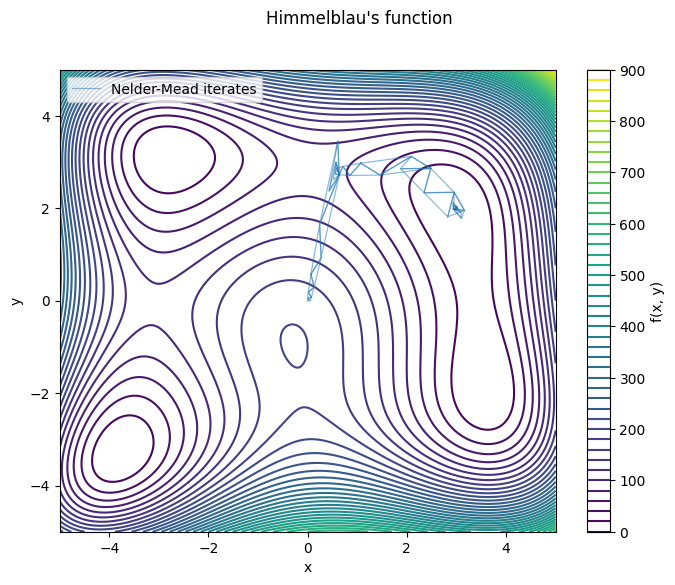

In [12]:
for i, simplex in enumerate(path_nelder_mead):
    simplex_closed = np.vstack([simplex, simplex[0]])
    ax.plot(
        simplex_closed[:, 0],
        simplex_closed[:, 1],
        color="tab:blue",
        alpha=0.5,
        linewidth=0.9,
        label ="Nelder-Mead iterates" if i == 0 else None,
    )
ax.legend(loc="upper left")
fig

`fmin_qnewton` is a local gradient-based method. If no gradient is supplied, the solver estimates it numerically by forward finite differences, which is convenient but usually more expensive and less accurate than providing an analytical expression.

In [13]:
path_qnewton = []
def callback_qnewton(k, xk, fk, gk):
    path_qnewton.append(xk.copy())
    return (False, False)

In [18]:
fmin_qnewton(himmelblau, x0, global_method="dogleg", callback=callback_qnewton)

 method: Quasi-Newton (Global: Dogleg, BFGS: Factored)
success: True
message: ||∇f(x)*sclf/sclx||∞ ≤ tolg
 nfeval: 61
 ngeval: 0
 nheval: 0
  niter: 18
      x: [2.99999994 2.        ]
      f: 1.3065687501838304e-13
      g: [-2.74148317e-06 -6.01026340e-07]
      H: []
      L: [[-8.80953297  0.        ]
 [-2.36020513 -5.34833719]]

When an analytical gradient is available, passing it explicitly usually reduces the total work. The optimizer follows the same local strategy, but avoids repeated finite-difference evaluations.

In [19]:
fmin_qnewton(himmelblau, x0, grad=himmelblau_grad, global_method="dogleg")

 method: Quasi-Newton (Global: Dogleg, BFGS: Factored)
success: True
message: ||∇f(x)*sclf/sclx||∞ ≤ tolg
 nfeval: 23
 ngeval: 19
 nheval: 0
  niter: 18
      x: [2.99999996 2.        ]
      f: 5.112433185319805e-14
      g: [-2.74148462e-06 -6.01024411e-07]
      H: []
      L: [[-8.80953313  0.        ]
 [-2.36020494 -5.34833715]]

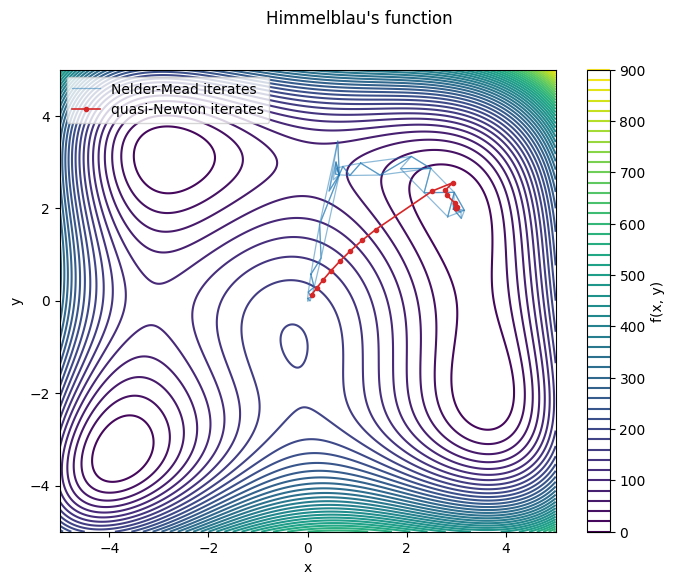

In [16]:
ax.plot(
    [point[0] for point in path_qnewton],
    [point[1] for point in path_qnewton],
    color="tab:red",
    marker="o",
    markersize=3,
    linewidth=1.2,
    label="quasi-Newton iterates",
)
ax.legend(loc="upper left")
fig

Starting from the same initial point, the quasi-Newton method follows a much more direct path than the Nelder–Mead simplex algorithm. As a result, it typically requires far fewer iterations and function evaluations.

In practice:

* use `fmin_qnewton` for smooth objective functions when you can provide a reasonable initial guess;
* provide `grad` whenever possible, as gradient information usually improves both efficiency and robustness;
* use `fmin_nelder_mead` when the objective function is noisy and derivatives cannot be estimated reliably.